<a href="https://colab.research.google.com/github/mojahedwali/machine-learning/blob/main/lab%203/my_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any machine learning project.  
In this notebook, we apply EDA on the House Prices dataset to understand:

- Dataset structure (rows/columns, data types)
- Missing values and duplicates
- Descriptive statistics
- Univariate and bivariate relationships with the target (SalePrice)
- Time-based trends using MoSold and YrSold


![step1.png](attachment:step1.png)

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")



Libraries imported successfully.


In [ ]:

# Load dataset
df = pd.read_csv("train.csv")

df.head()



# Dataset overview
print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Check Missing Values

In [ ]:
# Check missing values (first 5 rows)
df.isna().head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [ ]:
# Total missing values per column (sorted)
df.isna().sum().sort_values(ascending=False).head(25)



,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


### Check duplicate rows

In [ ]:
df.duplicated().sum()


np.int64(0)

### No. of rows and columns

In [ ]:
# finding number of rows and columns

print("Shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Shape (rows, columns): (1460, 81)
Number of rows: 1460
Number of columns: 81


### Data type of columns

In [ ]:
# viewing the data types of columns
df.dtypes


,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [ ]:
# Create SaleDate using YrSold and MoSold
df["SaleDate"] = pd.to_datetime(
    dict(year=df["YrSold"], month=df["MoSold"], day=1),
    errors="coerce"
)

df[["YrSold", "MoSold", "SaleDate"]].head()


,YrSold,MoSold,SaleDate
0,2008,2,2008-02-01
1,2007,5,2007-05-01
2,2008,9,2008-09-01
3,2006,2,2006-02-01
4,2008,12,2008-12-01


### Descriptive summary Statistics

In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Id,1460.0,NaN,NaN,NaN,730.5,1.0,365.75,730.5,1095.25,1460.0,421.610009
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,20.0,20.0,50.0,70.0,190.0,42.300571
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,21.0,59.0,69.0,80.0,313.0,24.284752
LotArea,1460.0,NaN,NaN,NaN,10516.828082,1300.0,7553.5,9478.5,11601.5,215245.0,9981.264932
...,...,...,...,...,...,...,...,...,...,...,...
YrSold,1460.0,NaN,NaN,NaN,2007.815753,2006.0,2007.0,2008.0,2009.0,2010.0,1.328095
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SalePrice,1460.0,NaN,NaN,NaN,180921.19589,34900.0,129975.0,163000.0,214000.0,755000.0,79442.502883


### Univariate Analysis

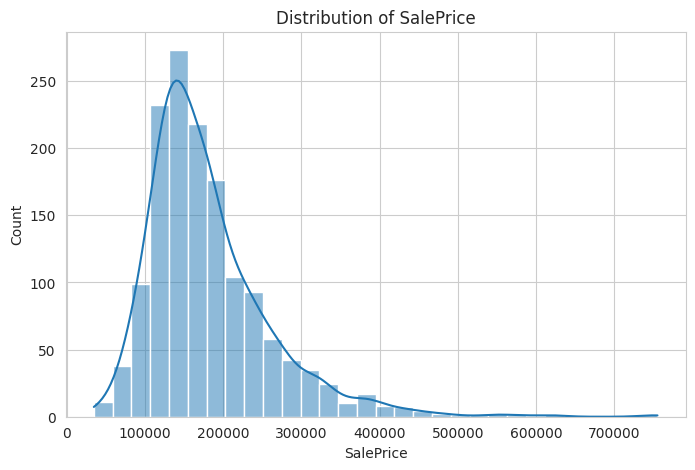

In [ ]:
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()


The distribution shows that SalePrice is slightly right-skewed,
which is common in real estate datasets.


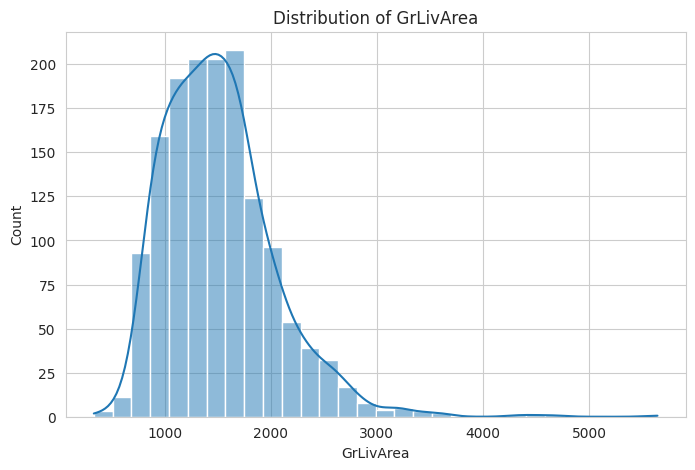

In [ ]:
sns.histplot(df["GrLivArea"], bins=30, kde=True)
plt.title("Distribution of GrLivArea")
plt.xlabel("GrLivArea")
plt.ylabel("Count")
plt.show()


## Bivariate Analysis
### SalePrice by Neighborhood


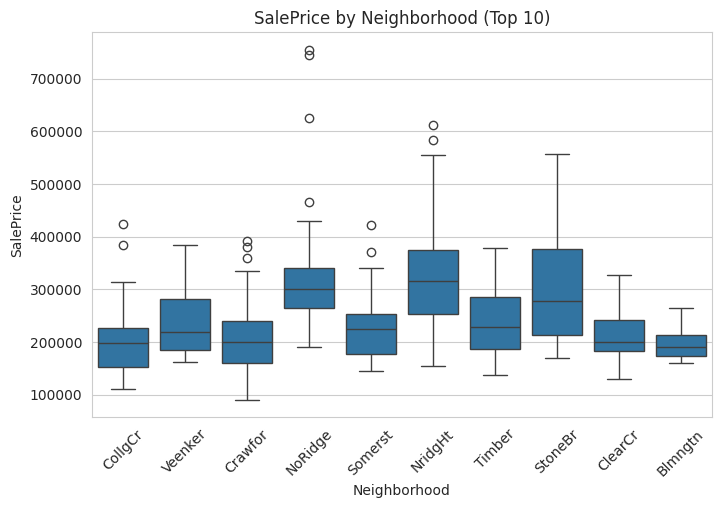

In [ ]:
top_neigh = (
    df.groupby("Neighborhood")["SalePrice"]
      .median()
      .sort_values(ascending=False)
      .head(10)
      .index
)

sns.boxplot(data=df[df["Neighborhood"].isin(top_neigh)],
            x="Neighborhood", y="SalePrice")
plt.xticks(rotation=45)
plt.title("SalePrice by Neighborhood (Top 10)")
plt.show()


### SalePrice by Overall Quality


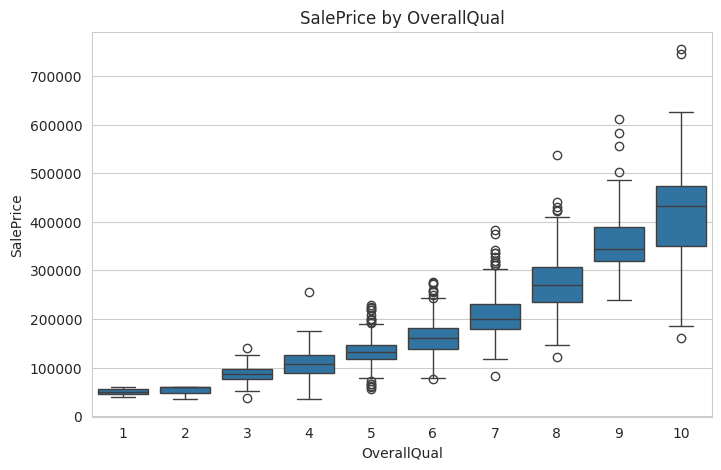

In [ ]:
sns.boxplot(data=df, x="OverallQual", y="SalePrice")
plt.title("SalePrice by OverallQual")
plt.show()


### Living Area vs SalePrice


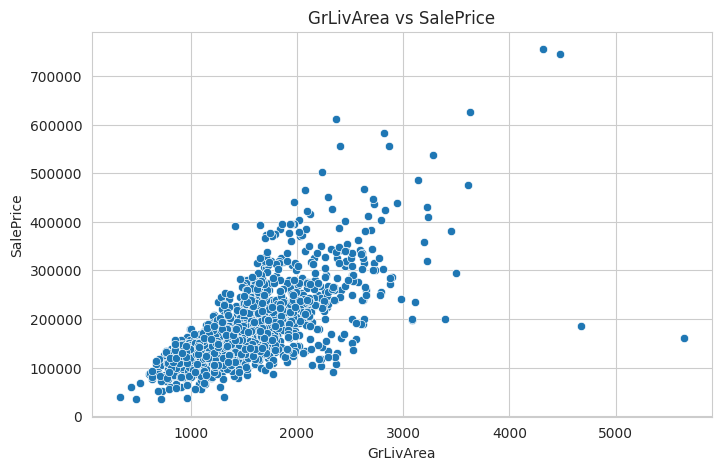

In [ ]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("GrLivArea vs SalePrice")
plt.show()


### Correlation Analysis


In [ ]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print("Top 15 correlated features with SalePrice:")
print(corr.head(15))


Top 15 correlated features with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


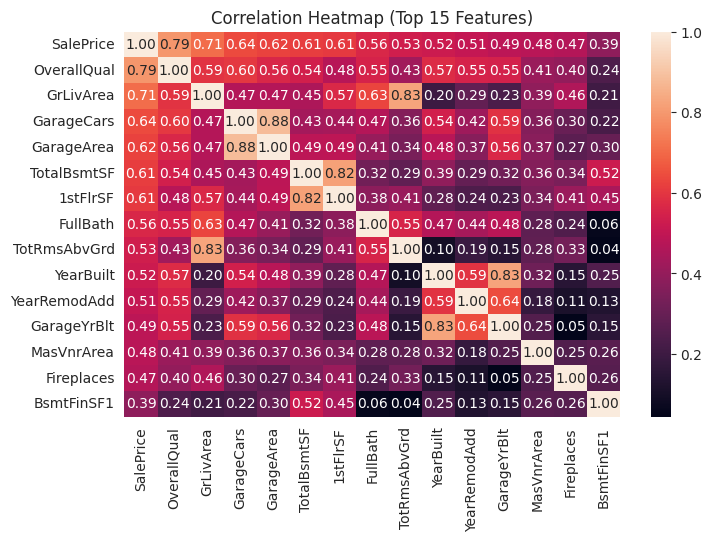

In [ ]:
top15 = corr.head(15).index

sns.heatmap(df[top15].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Top 15 Features)")
plt.show()


## Time-Based Analysis
### Monthly Median SalePrice Trend


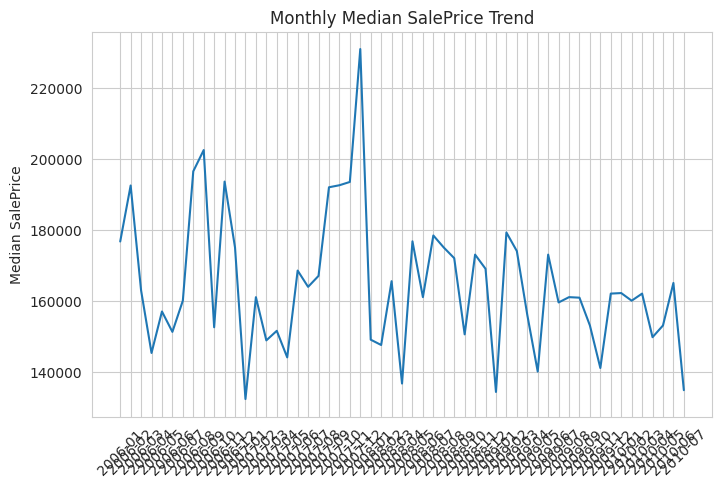

In [ ]:
monthly_median = (
    df.groupby(df["SaleDate"].dt.to_period("M"))["SalePrice"]
      .median()
      .sort_index()
)

monthly_median.index = monthly_median.index.astype(str)

plt.plot(monthly_median.index, monthly_median.values)
plt.xticks(rotation=45)
plt.title("Monthly Median SalePrice Trend")
plt.ylabel("Median SalePrice")
plt.show()


# Conclusion

The exploratory data analysis showed:

- SalePrice is right-skewed.
- OverallQual, GrLivArea, and Neighborhood strongly affect house prices.
- There are missing values in several features.
- Time trends show variation in monthly house prices.

These insights will help guide preprocessing and model building.
